In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os
import argparse
from torch.utils.data import DataLoader

import warnings
warnings.filterwarnings("ignore")

# Import your modules
# Ensure these files are accessible in the python path
from network.VAE import VIBCNN, VIBCNN_backup
from network.ResNet_IO import ResNetX
from network.CNN_IO import BinaryClassifier
from dataloader import MRIDataset1, MRIDataset2, MRIDataset3_2, MRIDataset2_2, MRIDataset1_2
import math

In [2]:
# SKE
MODEL_PATH = "/home/chunsup2/Downloads/SKEBKS_MRI/0.5/CNN_measure_lr5e-05_d3.pth"
DATA_PATH = '/shared/anastasio-s2/SI/HCP_selected/ske_3.0_0.05_35.0_c2_num_signals_diffusion_n/test/data.h5'

# SKS
# MODEL_PATH = "/home/chunsup2/PycharmProjects/VIBIO/checkpoints/sks_choose/1.0/VIBCE/VIBCNN_measure_d6_z16_kl0.001_lr0.005_b256_bestAUC.pth"
# MODEL_PATH = "/home/chunsup2/PycharmProjects/VIBIO/checkpoints/sks_choose/1.0/VIBIO/emaVIBCNN_measure_d6_z256_kl0.0001_lr0.005_io1.0_b256_bestAUC.pth"
# DATA_PATH = '/shared/anastasio-s2/SI/HCP_selected/sks_3.0_0.2_25.0_c2_num_signals_diffusion_n/test/data.h5'


CLS_TYPE = 'CNN'  # VIBCNN, ResNet, or CNN
DEPTH = 3  # Must match training
Z_DIM = 16  # Must match training
TRAIN_TYPE = 'measure'  # measure, cls
USE_RAM = 0  # 0 or 1, match training

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Args: pass
args = Args()
args.cls_type = CLS_TYPE
args.depth = DEPTH
args.z_dim = Z_DIM
args.train_type = TRAIN_TYPE
args.use_ram = USE_RAM
args.test_image_path = DATA_PATH

# 2. Initialize Model
print(f"Initializing {args.cls_type}...")
model = BinaryClassifier(args.depth, num_classes=2).to(device)

Initializing CNN...


In [9]:
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device)

    # Check if loading a full state dict or just parts
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    # Fix 'module.' prefix if it exists
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k.replace("module.", "")
        new_state_dict[name] = v

    model.load_state_dict(new_state_dict)
    print("Model weights loaded successfully.")

Model weights loaded successfully.


In [10]:
def _diagnose_broken_graph(model, input_tensor):
    """Helper to pinpoint EXACTLY which layer disconnects the gradient."""
    print("--- Diagnostic Report ---")
    x = input_tensor

    # Check Inc
    print(f"Input: requires_grad={x.requires_grad}")
    x = model.inc(x)
    print(f"After model.inc: requires_grad={x.requires_grad} (Should be True)")

    # Check Conv Layers
    for i, layer in enumerate(model.conv_layers):
        old_x = x
        x = layer(x)
        print(f"After ConvBlock {i}: requires_grad={x.requires_grad}")
        if not x.requires_grad:
            print(f"!!! BREAK DETECTED AT ConvBlock {i} !!!")
            print("Check if this block uses .detach(), numpy conversions, or aggressive inplace ops.")
            return

    # Check Flatten
    flat = x.view(x.size(0), -1)
    print(f"After flatten: requires_grad={flat.requires_grad}")

    # Check Mu
    mu = model.mu(flat)
    print(f"After model.mu: requires_grad={mu.requires_grad}")
    print("-------------------------")

In [22]:
data_idx = 1

with torch.enable_grad():
    model.eval()

    test_dataset = MRIDataset1_2(args.test_image_path, proportion=1.0)
    test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)

    data_batch = next(iter(test_dataloader))

    print('Class: ', data_batch[1])

    input_img = data_batch[0].clone().detach().requires_grad_(True).to(device)


Class:  tensor([1])


Visualizing Receptive Fields for Channel 0
Feature Map Size: 34x40


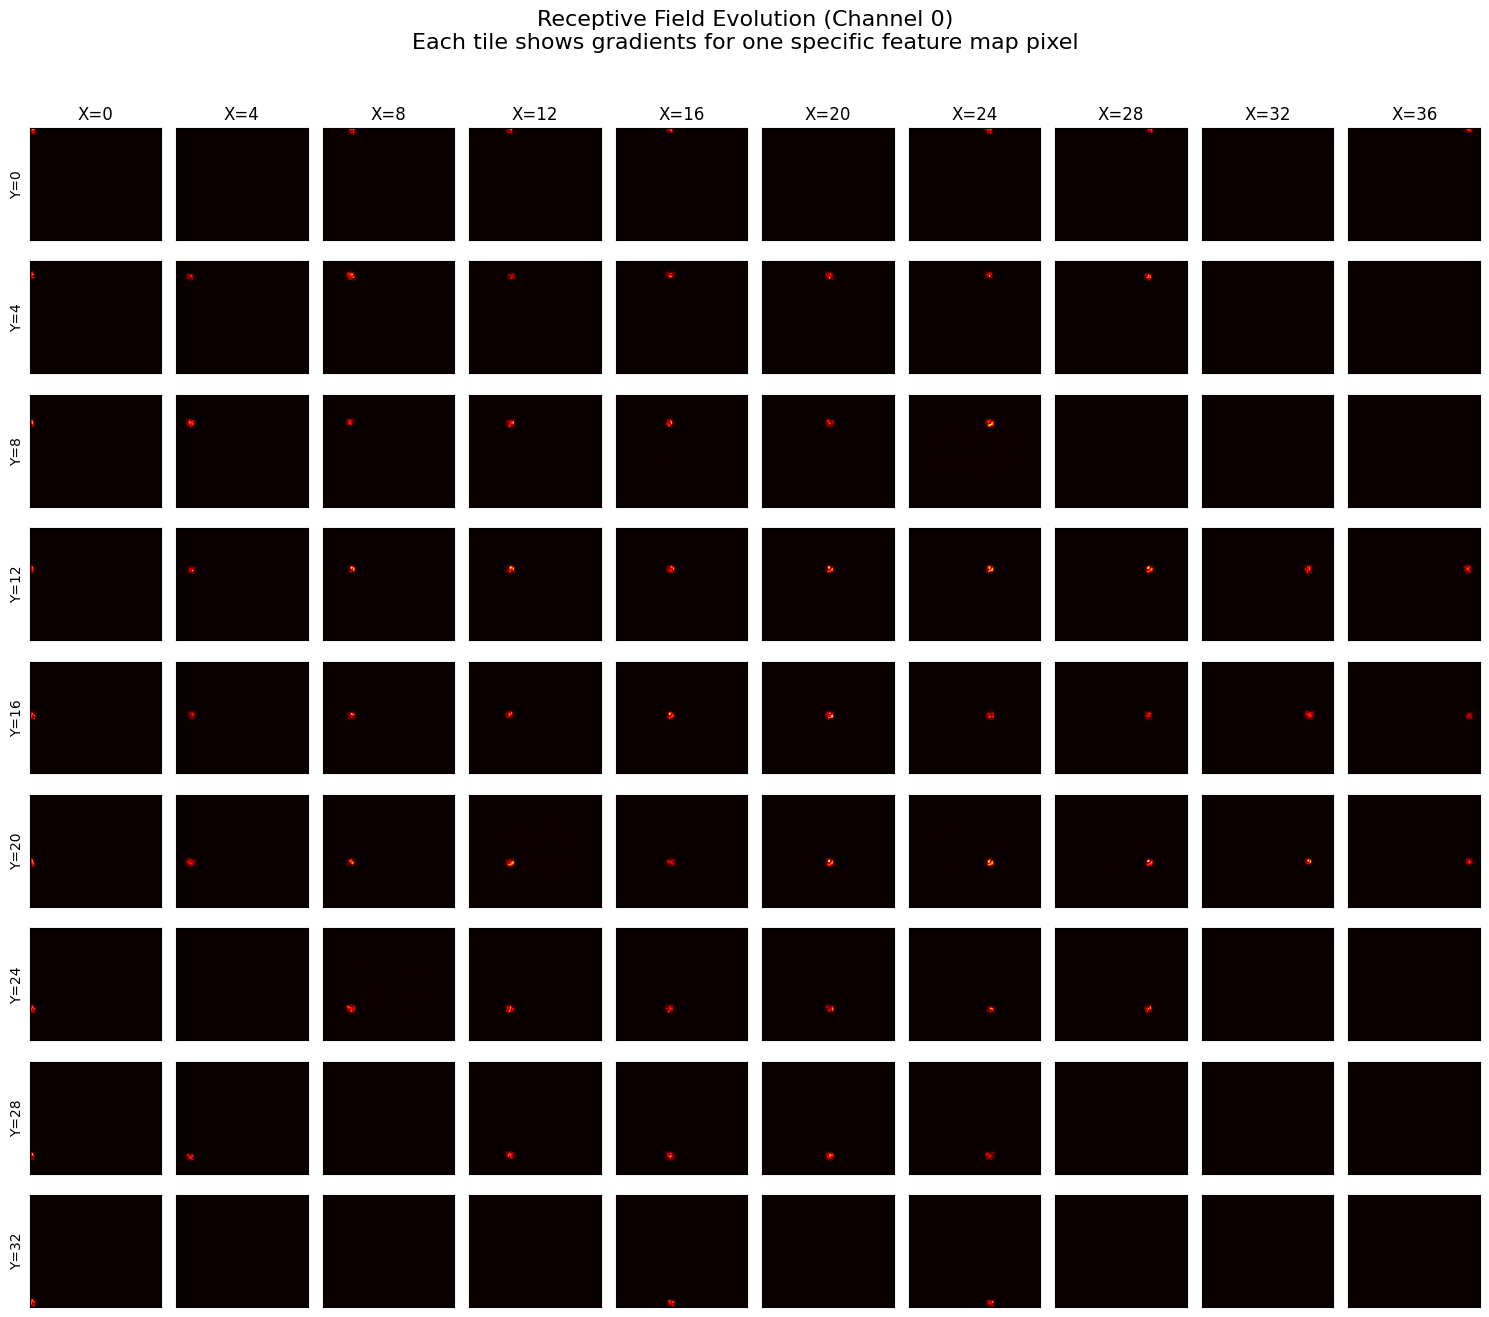

In [29]:
target_channel_idx = 0
step = 4
model.eval()

# Run through encoder layers
x = model.inc(input_img)
for layer in model.conv_layers:
    x = layer(x)

# x shape: (1, Channels, Height, Width)
feature_map = x
H_feat, W_feat = feature_map.shape[2], feature_map.shape[3]

print(f"Visualizing Receptive Fields for Channel {target_channel_idx}")
print(f"Feature Map Size: {H_feat}x{W_feat}")

# 2. Define the Grid of Pixels to Probe
# We don't want every single pixel (too slow), so we take steps
h_indices = range(0, H_feat, step)
w_indices = range(0, W_feat, step)

# Prepare Plot
rows = len(h_indices)
cols = len(w_indices)
fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
fig.suptitle(f"Receptive Field Evolution (Channel {target_channel_idx})\nEach tile shows gradients for one specific feature map pixel", fontsize=16)

# Flatten axes if necessary
if not isinstance(axes, np.ndarray): axes = np.array([[axes]])
if len(axes.shape) == 1: axes = axes.reshape(rows, cols)

# 3. Iterate and Backpropagate
for i, h in enumerate(h_indices):
    for j, w in enumerate(w_indices):
        # Zero grads
        model.zero_grad()
        if input_img.grad is not None:
            input_img.grad.zero_()

        # --- THE FIX ---
        # Instead of mean(), we target ONE SPECIFIC PIXEL at (h, w)
        target_scalar = feature_map[0, target_channel_idx, h, w]

        # Compute Gradient
        grads = torch.autograd.grad(
            outputs=target_scalar,
            inputs=input_img,
            retain_graph=True, # Essential because we reuse the graph loop
            allow_unused=True
        )[0]

        # Process Gradient
        if grads is not None:
            g = grads.detach().cpu().numpy().squeeze()
            g = np.abs(g)
            # Normalize per tile for visibility
            if g.max() > 0:
                g = (g - g.min()) / (g.max() - g.min())
        else:
            g = np.zeros_like(input_img.detach().cpu().numpy().squeeze())

        # Plot
        ax = axes[i, j]
        ax.imshow(g, cmap='hot')

        # Optional: Add a small dot to show where the 'center' should be roughly
        # This helps you verify if the receptive field aligns with geometry
        # ax.plot(w * (320/W_feat), h * (272/H_feat), 'bx', markersize=2, alpha=0.5)

        # Remove ticks for clean look
        ax.set_xticks([])
        ax.set_yticks([])

        # Label only on edges
        if j == 0: ax.set_ylabel(f"Y={h}")
        if i == 0: ax.set_title(f"X={w}")

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()